# Simulation study evaluation plots

Reads the tidy outputs of `extract_trans_eval.R` (`trans_eval_long.csv`) and
`extract_cis_mse.py` (`cis_eval.csv`) -- see `docs/SIMULATION_STUDY_PLAN.md` §8.

**Section 1-3d design (rewritten 2026-08-12)**:
- **"Separate plots" dimensions** vary by section, based on which facet slots are
  already used: sections 1 and 3c use `log2_o_x`/`log2_X_NTC` as *facets* (their only
  other facet candidates -- EC50/full log2FC -- don't apply), so their separate-plot
  axes are just `guide_shape x cells_per_gene x n_guides` (24 files each). Sections 2,
  3a, 3b, 3d already use both facet slots for `K_log2FC_true`/`full_log2FC_true`, so
  `log2_o_x`/`log2_X_NTC` become separate-plot axes too
  (`guide_shape x cells_per_gene x n_guides x log2_o_x x log2_X_NTC` = 240 files each).
- **`o_y_rel`** ("Low"/"High" overdispersion, built in the load cell): relative to each
  row's own `y_ntc_log2` group, since the actual `o_y_log2` pair differs by regime
  (`(-1.5, 0.0)` normally, `(-0.3, 2.0)` for `y_ntc_log2 == -4`) -- raw `o_y_log2` isn't
  comparable across y_ntc groups, so "high vs low o_y" always means this relative label,
  including in section 1 (which didn't originally specify relative vs raw).
- **`tpr_status`** (built in the load cell, `single_hill`-truth rows only): classification
  re-expressed against ground truth direction -- `"True single (correct direction)"`,
  `"False single (wrong direction)"` (detected as single, but the wrong sign),
  `"False additive"` (detected as needing both components -- `non_monotonic_min`/
  `non_monotonic_max`/`non_monotonic` are folded in here too, 2026-08-12 decision),
  `"False negative"` (`flat`, not detected). This replaces the earlier
  `detection_status` scheme entirely.
- **3a/3b/3c/3d are now ALL restricted to `tpr_status == "True single (correct
  direction)"`** -- a change from the previous version, where 3c included null-truth
  features too and 3d also kept `"False additive"` rows. Both of those are dropped now
  per the explicit restructure request ("3d is analogous to 3a").
- **Color palettes are fixed and non-default** (built once in the load cell, reused
  everywhere): `tpr_status_colors` (green = correct, orange = wrong direction,
  purple = wrong shape, red = missed), `o_y_rel_colors` (blue = low, red = high,
  standalone use in 1/3c), and `y_ntc_oy_colors` (section 3a/3b/3d: one HCL "Viridis"
  base hue per `y_ntc_log2` level, lightened for "Low" o_y -- so "colour by y_ntc, hue
  by o_y" is a single combined legend, not two separate aesthetics).
- `n_true`'s *magnitude* (not just sign) isn't used as a facet/axis anywhere in section
  2 or 3b -- only its sign feeds `tpr_status`. Flagged as a possible gap, left pooled
  for now (ask if you want it split out).

Section 0 (guide design) and section 4 (fit_cis MSE) are unchanged by this restructure.

## Step 0: extract inputs (run before this notebook, on the cluster)

```bash
$PYTHON_ENV $EXAMPLES/extract_cis_mse.py \
  --design_matrix $OUT/design_matrix.csv --data_root $DATA \
  --outfile $OUT/cis_eval.csv

Rscript $EXAMPLES/extract_trans_eval.R \
  --design_matrix $OUT/design_matrix.csv --data_root $DATA \
  --outfile $OUT/trans_eval_long.csv
```

Re-run both whenever the study's data on disk has changed (new completions,
resubmitted failures, ...) -- this notebook only reads the two CSVs they produce, it
never touches per-scenario fit output directly. Update `basedir` in the Config cell
below to match `$OUT` if it moved.

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(ggplot2)
})

Warning message:
“package ‘data.table’ was built under R version 4.4.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”


In [2]:
# --- Config -- edit these paths ---
basedir <- '/cfs/klemming/projects/snic/lappalainen_lab1/users/Leah/CRISPRmodelling/BayesianModelling/Simulations/sim-study-20260804T223922Z/'
trans_eval_path <- paste0(basedir, "trans_eval_long.csv")
cis_eval_path <- paste0(basedir, "cis_eval.csv")
outdir <- paste0(basedir, "./eval_plots")
dir.create(outdir, showWarnings = FALSE, recursive = TRUE)

In [3]:
my_plot_func <- function(p, width=5, height=4) {
    options(repr.plot.width=width, repr.plot.height=height)
    library(png)
    library(grid)
    ggsave("p_tmp.png", plot = p, width = width, height = height)
    img <- readPNG("p_tmp.png")
    grid.raster(img)
    grid.newpage()
}

save_plot <- function(p, name, width = 10, height = 8) {
  # Displays inline (IRkernel auto-prints the last expression of a cell, but not
  # inside a loop/function call, so this prints explicitly) and saves to PDF.
  my_plot_func(p, width, height)
  path <- file.path(outdir, paste0(name, ".pdf"))
  ggsave(path, p, width = width, height = height, limitsize = FALSE)
  invisible(p)
}

In [4]:
trans_eval <- fread(trans_eval_path)
cis_eval <- fread(cis_eval_path)

# Shared derived columns
trans_eval[, y_ntc_log2_fit := log2(y_ntc)]
guide_shapes <- sort(unique(trans_eval$guide_shape))

# o_y_rel: "Low"/"High" overdispersion RELATIVE to that row's y_ntc_log2 group (the
# actual o_y_log2 pair differs by y_ntc regime -- (-1.5, 0.0) normally, (-0.3, 2.0)
# for y_ntc_log2 == -4 -- so raw o_y_log2 isn't comparable across y_ntc groups; this
# relative label is what "high vs low o_y" means throughout sections 1-3d).
trans_eval[, o_y_rel := factor(ifelse(o_y_log2 == min(o_y_log2), "Low", "High"),
                                levels = c("Low", "High")), by = y_ntc_log2]

# tpr_status: classification re-expressed relative to ground truth direction, for
# single_hill-truth features only (NA for no_effect rows -- see section 1 for those).
# non_monotonic_min/non_monotonic_max/non_monotonic are folded into "False additive"
# (a fit that didn't converge to a single clean recovered curve), 2026-08-12 decision.
trans_eval[, tpr_status := fcase(
  effect_type == "single_hill" & ((classification == "single_positive" & n_true > 0) |
                                   (classification == "single_negative" & n_true < 0)),
  "True single (correct direction)",
  effect_type == "single_hill" & ((classification == "single_positive" & n_true < 0) |
                                   (classification == "single_negative" & n_true > 0)),
  "False single (wrong direction)",
  effect_type == "single_hill" & classification %in% c("additive_positive", "additive_negative",
                                                         "non_monotonic_min", "non_monotonic_max",
                                                         "non_monotonic"),
  "False additive",
  effect_type == "single_hill" & classification == "flat",
  "False negative"
)]
trans_eval[, tpr_status := factor(tpr_status, levels = c(
  "True single (correct direction)", "False single (wrong direction)",
  "False additive", "False negative"))]

# Fixed, non-default color palettes -----------------------------------------------

# tpr_status: green = correctly recovered, orange = detected but wrong direction,
# purple = detected but wrong shape (additive/non-monotonic), red = missed entirely.
tpr_status_colors <- c(
  "True single (correct direction)" = "#1B9E77",
  "False single (wrong direction)"  = "#D95F02",
  "False additive"                  = "#7570B3",
  "False negative"                  = "#E41A1C"
)

# o_y_rel (standalone, e.g. section 1/3c): blue = low overdispersion, red = high.
o_y_rel_colors <- c("Low" = "#2C7BB6", "High" = "#D7191C")

# y_ntc x o_y_rel combined palette (section 3a/3b/3d, "colour by y_ntc, hue by o_y"):
# one base hue per y_ntc_log2 level from a perceptually-uniform, colorblind-safe HCL
# "Viridis" ramp (not ggplot's default hue wheel), ordered low->high y_ntc; "High"
# overdispersion keeps the base (saturated) color, "Low" gets a lightened tint of the
# SAME hue -- so both variables are visible from one combined legend/aesthetic.
.lighten <- function(hex, amount = 0.55) colorRampPalette(c(hex, "white"))(101)[round(amount * 100) + 1]
y_ntc_levels <- sort(unique(trans_eval$y_ntc_log2))
y_ntc_base <- setNames(hcl.colors(length(y_ntc_levels), palette = "Viridis"), as.character(y_ntc_levels))
y_ntc_oy_combo <- data.table(y_ntc_log2 = rep(y_ntc_levels, each = 2),
                              o_y_rel = rep(c("High", "Low"), times = length(y_ntc_levels)))
y_ntc_oy_combo[, base := y_ntc_base[as.character(y_ntc_log2)]]
y_ntc_oy_combo[, color := ifelse(o_y_rel == "High", base, sapply(base, .lighten))]
y_ntc_oy_combo[, key := paste0("y_ntc=", y_ntc_log2, ", ", o_y_rel, " o_y")]
y_ntc_oy_colors <- setNames(y_ntc_oy_combo$color, y_ntc_oy_combo$key)

trans_eval[, y_ntc_oy_key := factor(paste0("y_ntc=", y_ntc_log2, ", ", o_y_rel, " o_y"),
                                     levels = y_ntc_oy_combo$key)]

cat(sprintf("Loaded %d trans_eval rows, %d cis_eval rows, guide_shapes = %s\n",
            nrow(trans_eval), nrow(cis_eval), paste(guide_shapes, collapse = ", ")))
cat("tpr_status counts (single_hill truth only):\n")
print(trans_eval[effect_type == "single_hill", .N, by = tpr_status])

Loaded 2601830 trans_eval rows, 1200 cis_eval rows, guide_shapes = even, gap, small
detection_status counts:
   detection_status       N
             <fctr>   <int>
1:   False negative 2197847
2:    True positive  390566
3:    True negative   11879
4:             <NA>    1365
5:   False positive     108
6:   False additive      65


## 0. Cis simulation guide design

Visualizes the per-guide sampling distribution used to simulate cis expression
(`simulate_cis_panel` in `bayesDREAM/simulation/cis_panel_simulation.py`, mirrors
`_model_x`'s generative process): for guide *g*, per-cell `log2(x_true)` is drawn
as `Normal(log2(X_NTC) + guide_log2FC_g, sigma_eff)`, i.e. in log2FC-relative-to-NTC
space each guide (including NTC itself, whose `guide_log2FC = 0`) is
`Normal(guide_log2FC_g, sigma_eff)`. `sigma_eff` (0.7) is a single constant shared
by every guide/scenario in the study, so only the mean differs guide-to-guide --
these curves are the actual design (`GUIDE_PATTERNS`), not simulated draws or
output data, so this section needs no `trans_eval`/`cis_eval` loaded.

**NOTE**: `guide_patterns_r`/`sigma_eff` below are a hand-transcribed copy of
`GUIDE_PATTERNS`/`SIGMA_EFF` in `cis_panel_simulation.py` / `build_design_matrix.py`
(no Python/R interop in this notebook) -- if those change, update here too.

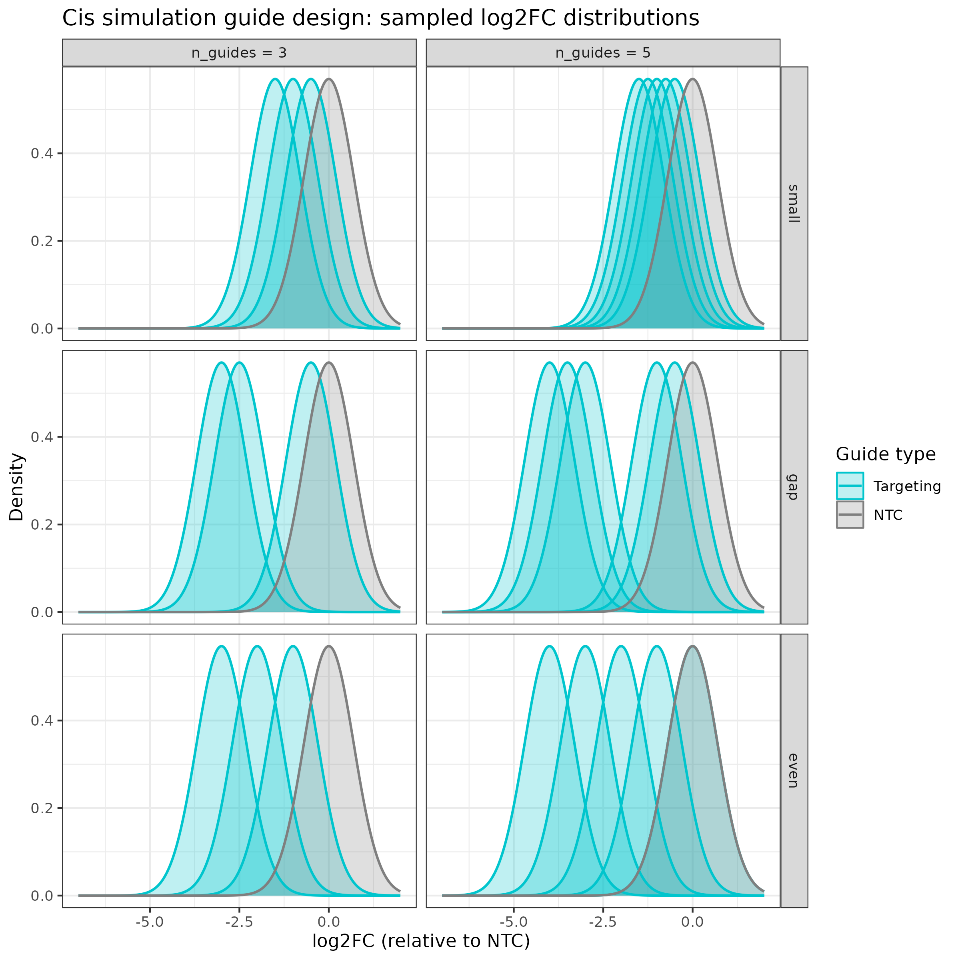

In [5]:
sigma_eff <- 0.7  # SIGMA_EFF, build_design_matrix.py

# GUIDE_PATTERNS, cis_panel_simulation.py -- keys are "n_guides_shape"
guide_patterns_r <- list(
  "3_even"  = c(-3, -2, -1),
  "3_gap"   = c(-3, -2.5, -0.5),
  "3_small" = c(-1.5, -1, -0.5),
  "5_even"  = c(-4, -3, -2, -1, 0),
  "5_gap"   = c(-4, -3.5, -3, -1, -0.5),
  "5_small" = c(-1.5, -1.25, -1, -0.75, -0.5)
)

x_grid <- seq(-7, 2, length.out = 400)
guide_density_grid <- rbindlist(lapply(names(guide_patterns_r), function(key) {
  parts <- strsplit(key, "_")[[1]]
  n_g <- as.integer(parts[1])
  shape <- parts[2]
  fcs <- guide_patterns_r[[key]]
  targeting <- rbindlist(lapply(seq_along(fcs), function(i) {
    data.table(n_guides = n_g, guide_shape = shape, guide = paste0("g", i), is_ntc = FALSE,
               x = x_grid, density = dnorm(x_grid, mean = fcs[i], sd = sigma_eff))
  }))
  ntc <- data.table(n_guides = n_g, guide_shape = shape, guide = "NTC", is_ntc = TRUE,
                     x = x_grid, density = dnorm(x_grid, mean = 0, sd = sigma_eff))
  rbind(targeting, ntc)
}))
guide_density_grid[, guide_shape := factor(guide_shape, levels = c("small", "gap", "even"))]
guide_density_grid[, n_guides := factor(n_guides, levels = c(3, 5))]
guide_density_grid[, guide_id := paste(n_guides, guide_shape, guide, sep = "_")]

p <- ggplot(guide_density_grid, aes(x = x, y = density, group = guide_id,
                                     color = is_ntc, fill = is_ntc)) +
  geom_area(position = "identity", alpha = 0.25) +
  geom_line(linewidth = 0.7) +
  scale_color_manual(values = c(`TRUE` = "grey50", `FALSE` = "turquoise3"),
                      labels = c(`TRUE` = "NTC", `FALSE` = "Targeting"), name = "Guide type") +
  scale_fill_manual(values = c(`TRUE` = "grey50", `FALSE` = "turquoise3"),
                     labels = c(`TRUE` = "NTC", `FALSE` = "Targeting"), name = "Guide type") +
  facet_grid(guide_shape ~ n_guides, labeller = labeller(n_guides = function(x) paste("n_guides =", x))) +
  labs(x = "log2FC (relative to NTC)", y = "Density",
       title = "Cis simulation guide design: sampled log2FC distributions") +
  theme_bw()
save_plot(p, "0_guide_design_densities", width = 8, height = 8)

## 1. False positive rate

Line plot per (`guide_shape`, `cells_per_gene`, `n_guides`) combination (24 separate
figures): x = `y_ntc_log2`, y = FPR (proportion of `no_effect`-truth features called
`is_dependent`), color = `o_y_rel`. Faceted by `log2_o_x` (rows) x `log2_X_NTC` (cols)
within each figure.

In [ ]:
fpr_data <- trans_eval[effect_type == "no_effect"]

make_fpr_lineplot <- function(dt, title_suffix) {
  agg <- dt[, .(fpr = mean(as.logical(is_dependent), na.rm = TRUE)),
            by = .(y_ntc_log2, o_y_rel, log2_X_NTC, log2_o_x)]
  ggplot(agg, aes(x = y_ntc_log2, y = fpr, color = o_y_rel)) +
    geom_line() + geom_point(size = 1.5) +
    scale_color_manual(values = o_y_rel_colors, name = "Overdispersion") +
    facet_grid(log2_o_x ~ log2_X_NTC,
               labeller = labeller(log2_o_x = function(x) paste("o_x =", x),
                                    log2_X_NTC = function(x) paste("x_ntc =", x))) +
    ylim(0, 1) +
    labs(x = "y_ntc (log2)", y = "False positive rate",
         title = paste("FPR --", title_suffix)) +
    theme_bw()
}

In [ ]:
for (shape in guide_shapes) {
  for (cpg in sort(unique(trans_eval$cells_per_gene))) {
    for (ng in sort(unique(trans_eval$n_guides))) {
      sub <- fpr_data[guide_shape == shape & cells_per_gene == cpg & n_guides == ng]
      if (nrow(sub) == 0) next
      save_plot(make_fpr_lineplot(sub, paste0("shape=", shape, ", cells_per_gene=", cpg,
                                                ", n_guides=", ng)),
                paste0("1_FPR_", shape, "_cpg", cpg, "_ng", ng), width = 10, height = 6)
    }
  }
}

## 2. True positive rate breakdown

Stacked bar per (`guide_shape`, `cells_per_gene`, `n_guides`, `log2_o_x`,
`log2_X_NTC`) combination (240 separate figures -- o_x/x_ntc are separate plots here,
not facets, since both facet slots are used by EC50/full log2FC). x = `y_ntc_log2` x
`o_y_rel` (2 bars per y_ntc value), fill = `tpr_status`. Faceted by `full_log2FC_true`
(rows) x `K_log2FC_true` (cols).

In [ ]:
tpr_data <- trans_eval[effect_type == "single_hill" & !is.na(tpr_status)]

make_tpr_stackedbar <- function(dt, title_suffix) {
  agg <- dt[, .N, by = .(y_ntc_log2, o_y_rel, K_log2FC_true, full_log2FC_true, tpr_status)]
  agg[, prop := N / sum(N), by = .(y_ntc_log2, o_y_rel, K_log2FC_true, full_log2FC_true)]
  y_ntc_sorted <- sort(unique(dt$y_ntc_log2))
  x_levels <- as.vector(sapply(y_ntc_sorted, function(y) paste0(y, "_", c("Low", "High"))))
  agg[, x_key := factor(paste0(y_ntc_log2, "_", o_y_rel), levels = x_levels)]
  ggplot(agg, aes(x = x_key, y = prop, fill = tpr_status)) +
    geom_col(position = "stack") +
    scale_fill_manual(values = tpr_status_colors, name = "Outcome") +
    facet_grid(full_log2FC_true ~ K_log2FC_true,
               labeller = labeller(full_log2FC_true = function(x) paste("full log2FC =", x),
                                    K_log2FC_true = function(x) paste("EC50 =", x))) +
    labs(x = "y_ntc (log2) / overdispersion (Low, High)", y = "Proportion",
         title = paste("TPR breakdown --", title_suffix)) +
    theme_bw() + theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6))
}

In [ ]:
for (shape in guide_shapes) {
  for (cpg in sort(unique(trans_eval$cells_per_gene))) {
    for (ng in sort(unique(trans_eval$n_guides))) {
      for (ox in sort(unique(trans_eval$log2_o_x))) {
        for (xntc in sort(unique(trans_eval$log2_X_NTC))) {
          sub <- tpr_data[guide_shape == shape & cells_per_gene == cpg & n_guides == ng &
                             log2_o_x == ox & log2_X_NTC == xntc]
          if (nrow(sub) == 0) next
          save_plot(make_tpr_stackedbar(sub, paste0("shape=", shape, ", cpg=", cpg, ", ng=", ng,
                                                      ", o_x=", ox, ", x_ntc=", xntc)),
                    paste0("2_TPR_", shape, "_cpg", cpg, "_ng", ng, "_ox", ox, "_xntc", xntc),
                    width = 16, height = 10)
        }
      }
    }
  }
}

## 3. Estimated vs true

3a/3b/3c/3d are all restricted to `tpr_status == "True single (correct direction)"`
(see load cell) -- ground truth is `single_hill` AND the fit correctly recovered a
single Hill curve in the correct direction.

### 3a. Hill exponent `n`

x = true `n` (x-jittered), y = estimated `n`. Color = `y_ntc_oy_key` (combined
y_ntc/o_y palette). Faceted by `K_log2FC_true` (cols) x `full_log2FC_true` (rows).
Dashed line marks y = x. One figure per (`guide_shape`, `cells_per_gene`, `n_guides`,
`log2_o_x`, `log2_X_NTC`) combination (240 figures).

In [ ]:
sh_active_n <- trans_eval[effect_type == "single_hill" &
                             tpr_status == "True single (correct direction)" &
                             !is.na(estimated_n)]

make_n_scatter <- function(dt, title_suffix) {
  ggplot(dt, aes(x = n_true, y = estimated_n, color = y_ntc_oy_key)) +
    geom_jitter(width = 0.15, height = 0, size = 1, alpha = 0.6) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40") +
    scale_color_manual(values = y_ntc_oy_colors, name = "y_ntc / overdispersion") +
    facet_grid(full_log2FC_true ~ K_log2FC_true,
               labeller = labeller(full_log2FC_true = function(x) paste("full log2FC =", x),
                                    K_log2FC_true = function(x) paste("EC50 =", x))) +
    labs(x = "True n", y = "Estimated n", title = paste("n estimated vs true --", title_suffix)) +
    theme_bw()
}

In [ ]:
tmp <- trans_eval[(guide_shape=='even') &
                   (n_guides==5) &
                   (cells_per_gene == 1000) &
                   (y_ntc_log2 == 4) &
                   (o_y_log2 == -1.5) &
                   (log2_X_NTC == 1) & # why is this not 2? have these not run yet?
                   (log2_o_x == -1.5) &
                   (full_log2FC_true == 4.0)
                   ]

In [ ]:
  table(trans_eval[(guide_shape=='even') & (n_guides==5) & (cells_per_gene==1000) &
                    (log2_X_NTC==1) & (log2_o_x==-1.5)]$replicate_id)

In [ ]:
p <- ggplot(tmp, aes(x = n_true)) +
    geom_point(aes(y = estimated_n, colour=classification)) +
    geom_point(aes(y=n_true), shape='x', colour='red') +
    facet_wrap( ~ K_log2FC_true, nrow=1) +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
my_plot_func(p, width=20, height=4)

In [ ]:
colnames(sh_active_n)

In [ ]:
sh_active_n[,.N,by=c("n_true", "full_log2FC_true")]

In [ ]:
for (shape in guide_shapes) {
  for (cpg in sort(unique(trans_eval$cells_per_gene))) {
    for (ng in sort(unique(trans_eval$n_guides))) {
      for (ox in sort(unique(trans_eval$log2_o_x))) {
        for (xntc in sort(unique(trans_eval$log2_X_NTC))) {
          sub <- sh_active_n[guide_shape == shape & cells_per_gene == cpg & n_guides == ng &
                                log2_o_x == ox & log2_X_NTC == xntc]
          if (nrow(sub) == 0) next
          save_plot(make_n_scatter(sub, paste0("shape=", shape, ", cpg=", cpg, ", ng=", ng,
                                                  ", o_x=", ox, ", x_ntc=", xntc)),
                    paste0("3a_n_", shape, "_cpg", cpg, "_ng", ng, "_ox", ox, "_xntc", xntc),
                    width = 16, height = 9)
        }
      }
    }
  }
}

### 3b. EC50 (log2FC)

x = true EC50 (`K_log2FC_true`, x-jittered), y = estimated EC50. Color =
`y_ntc_oy_key`. No x-facet; y-facet = `full_log2FC_true`. Dashed line marks y = x.
One figure per (`guide_shape`, `cells_per_gene`, `n_guides`, `log2_o_x`,
`log2_X_NTC`) combination (240 figures).

In [ ]:
sh_active_k <- trans_eval[effect_type == "single_hill" &
                             tpr_status == "True single (correct direction)" &
                             !is.na(estimated_K_log2FC)]

make_ec50_scatter <- function(dt, title_suffix) {
  ggplot(dt, aes(x = K_log2FC_true, y = estimated_K_log2FC, color = y_ntc_oy_key)) +
    geom_jitter(width = 0.15, height = 0, size = 1, alpha = 0.6) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40") +
    scale_color_manual(values = y_ntc_oy_colors, name = "y_ntc / overdispersion") +
    facet_grid(full_log2FC_true ~ .,
               labeller = labeller(full_log2FC_true = function(x) paste("full log2FC =", x))) +
    labs(x = "True EC50 (log2FC)", y = "Estimated EC50 (log2FC)",
         title = paste("EC50 estimated vs true --", title_suffix)) +
    theme_bw()
}

In [ ]:
for (shape in guide_shapes) {
  for (cpg in sort(unique(trans_eval$cells_per_gene))) {
    for (ng in sort(unique(trans_eval$n_guides))) {
      for (ox in sort(unique(trans_eval$log2_o_x))) {
        for (xntc in sort(unique(trans_eval$log2_X_NTC))) {
          sub <- sh_active_k[guide_shape == shape & cells_per_gene == cpg & n_guides == ng &
                                log2_o_x == ox & log2_X_NTC == xntc]
          if (nrow(sub) == 0) next
          save_plot(make_ec50_scatter(sub, paste0("shape=", shape, ", cpg=", cpg, ", ng=", ng,
                                                     ", o_x=", ox, ", x_ntc=", xntc)),
                    paste0("3b_EC50_", shape, "_cpg", cpg, "_ng", ng, "_ox", ox, "_xntc", xntc),
                    width = 6, height = 10)
        }
      }
    }
  }
}

### 3b (alt). EC50, faceted by true `n` too

Same as 3b above, but using the free x-facet slot for `n_true` instead of pooling
across it (`n_true` magnitude was pooled in section 2 and the main 3b by request --
this is the faceted alternative to compare against). x-facet = `n_true`, y-facet =
`full_log2FC_true`.

In [ ]:
make_ec50_scatter_facetn <- function(dt, title_suffix) {
  ggplot(dt, aes(x = K_log2FC_true, y = estimated_K_log2FC, color = y_ntc_oy_key)) +
    geom_jitter(width = 0.15, height = 0, size = 1, alpha = 0.6) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40") +
    scale_color_manual(values = y_ntc_oy_colors, name = "y_ntc / overdispersion") +
    facet_grid(full_log2FC_true ~ n_true,
               labeller = labeller(full_log2FC_true = function(x) paste("full log2FC =", x),
                                    n_true = function(x) paste("n =", x))) +
    labs(x = "True EC50 (log2FC)", y = "Estimated EC50 (log2FC)",
         title = paste("EC50 estimated vs true (faceted by n) --", title_suffix)) +
    theme_bw()
}

In [ ]:
for (shape in guide_shapes) {
  for (cpg in sort(unique(trans_eval$cells_per_gene))) {
    for (ng in sort(unique(trans_eval$n_guides))) {
      for (ox in sort(unique(trans_eval$log2_o_x))) {
        for (xntc in sort(unique(trans_eval$log2_X_NTC))) {
          sub <- sh_active_k[guide_shape == shape & cells_per_gene == cpg & n_guides == ng &
                                log2_o_x == ox & log2_X_NTC == xntc]
          if (nrow(sub) == 0) next
          save_plot(make_ec50_scatter_facetn(sub, paste0("shape=", shape, ", cpg=", cpg, ", ng=", ng,
                                                            ", o_x=", ox, ", x_ntc=", xntc)),
                    paste0("3b_EC50_facetN_", shape, "_cpg", cpg, "_ng", ng, "_ox", ox, "_xntc", xntc),
                    width = 14, height = 10)
        }
      }
    }
  }
}

### 3c. `y_ntc`

x = true `y_ntc_log2` (discrete), y = estimated (`y_ntc_log2_fit`). Boxplot, fill =
`o_y_rel`. Faceted by `log2_o_x` (rows) x `log2_X_NTC` (cols). One figure per
(`guide_shape`, `cells_per_gene`, `n_guides`) combination (24 figures).

In [ ]:
sh_yntc <- trans_eval[effect_type == "single_hill" &
                         tpr_status == "True single (correct direction)" &
                         !is.na(y_ntc_log2_fit)]

make_yntc_boxplot <- function(dt, title_suffix) {
  ggplot(dt, aes(x = factor(y_ntc_log2), y = y_ntc_log2_fit, fill = o_y_rel)) +
    geom_boxplot(outlier.size = 0.5, position = position_dodge(width = 0.8)) +
    geom_point(aes(y = y_ntc_log2), shape = 4, color = "black", size = 1.2, alpha = 0.4,
               position = position_dodge(width = 0.8)) +
    scale_fill_manual(values = o_y_rel_colors, name = "Overdispersion") +
    facet_grid(log2_o_x ~ log2_X_NTC,
               labeller = labeller(log2_o_x = function(x) paste("o_x =", x),
                                    log2_X_NTC = function(x) paste("x_ntc =", x))) +
    labs(x = "True y_ntc (log2)", y = "Estimated y_ntc (log2)",
         title = paste("y_ntc estimated vs true --", title_suffix)) +
    theme_bw()
}

In [ ]:
for (shape in guide_shapes) {
  for (cpg in sort(unique(trans_eval$cells_per_gene))) {
    for (ng in sort(unique(trans_eval$n_guides))) {
      sub <- sh_yntc[guide_shape == shape & cells_per_gene == cpg & n_guides == ng]
      if (nrow(sub) == 0) next
      save_plot(make_yntc_boxplot(sub, paste0("shape=", shape, ", cells_per_gene=", cpg,
                                                ", n_guides=", ng)),
                paste0("3c_yntc_", shape, "_cpg", cpg, "_ng", ng), width = 10, height = 6)
    }
  }
}

### 3d. Full log2FC

Analogous to 3a: x = true full log2FC (`full_log2FC_true`, x-jittered), y = estimated
(`full_log2fc_median`). Color = `y_ntc_oy_key`. x-facet = `K_log2FC_true`; no y-facet
(full_log2FC_true is now the x-axis). One figure per (`guide_shape`, `cells_per_gene`,
`n_guides`, `log2_o_x`, `log2_X_NTC`) combination (240 figures).

In [ ]:
sh_fc <- trans_eval[effect_type == "single_hill" &
                       tpr_status == "True single (correct direction)" &
                       !is.na(full_log2fc_median)]

make_fulllog2fc_scatter <- function(dt, title_suffix) {
  ggplot(dt, aes(x = full_log2FC_true, y = full_log2fc_median, color = y_ntc_oy_key)) +
    geom_jitter(width = 0.1, height = 0, size = 1, alpha = 0.6) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40") +
    scale_color_manual(values = y_ntc_oy_colors, name = "y_ntc / overdispersion") +
    facet_grid(. ~ K_log2FC_true,
               labeller = labeller(K_log2FC_true = function(x) paste("EC50 =", x))) +
    labs(x = "True full log2FC", y = "Estimated full log2FC",
         title = paste("full log2FC estimated vs true --", title_suffix)) +
    theme_bw()
}

In [ ]:
for (shape in guide_shapes) {
  for (cpg in sort(unique(trans_eval$cells_per_gene))) {
    for (ng in sort(unique(trans_eval$n_guides))) {
      for (ox in sort(unique(trans_eval$log2_o_x))) {
        for (xntc in sort(unique(trans_eval$log2_X_NTC))) {
          sub <- sh_fc[guide_shape == shape & cells_per_gene == cpg & n_guides == ng &
                          log2_o_x == ox & log2_X_NTC == xntc]
          if (nrow(sub) == 0) next
          save_plot(make_fulllog2fc_scatter(sub, paste0("shape=", shape, ", cpg=", cpg, ", ng=", ng,
                                                           ", o_x=", ox, ", x_ntc=", xntc)),
                    paste0("3d_fulllog2fc_", shape, "_cpg", cpg, "_ng", ng, "_ox", ox, "_xntc", xntc),
                    width = 16, height = 5)
        }
      }
    }
  }
}

### 3d (alt). Full log2FC, faceted by true `n` too

Same as 3d above, but using the free y-facet slot for `n_true` instead of pooling
across it. x-facet = `K_log2FC_true` (unchanged), y-facet = `n_true`.

In [ ]:
make_fulllog2fc_scatter_facetn <- function(dt, title_suffix) {
  ggplot(dt, aes(x = full_log2FC_true, y = full_log2fc_median, color = y_ntc_oy_key)) +
    geom_jitter(width = 0.1, height = 0, size = 1, alpha = 0.6) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey40") +
    scale_color_manual(values = y_ntc_oy_colors, name = "y_ntc / overdispersion") +
    facet_grid(n_true ~ K_log2FC_true,
               labeller = labeller(n_true = function(x) paste("n =", x),
                                    K_log2FC_true = function(x) paste("EC50 =", x))) +
    labs(x = "True full log2FC", y = "Estimated full log2FC",
         title = paste("full log2FC estimated vs true (faceted by n) --", title_suffix)) +
    theme_bw()
}

In [ ]:
for (shape in guide_shapes) {
  for (cpg in sort(unique(trans_eval$cells_per_gene))) {
    for (ng in sort(unique(trans_eval$n_guides))) {
      for (ox in sort(unique(trans_eval$log2_o_x))) {
        for (xntc in sort(unique(trans_eval$log2_X_NTC))) {
          sub <- sh_fc[guide_shape == shape & cells_per_gene == cpg & n_guides == ng &
                          log2_o_x == ox & log2_X_NTC == xntc]
          if (nrow(sub) == 0) next
          save_plot(make_fulllog2fc_scatter_facetn(sub, paste0("shape=", shape, ", cpg=", cpg, ", ng=", ng,
                                                                  ", o_x=", ox, ", x_ntc=", xntc)),
                    paste0("3d_fulllog2fc_facetN_", shape, "_cpg", cpg, "_ng", ng, "_ox", ox, "_xntc", xntc),
                    width = 16, height = 12)
        }
      }
    }
  }
}

## 4. fit_cis accuracy: MSE of log2(x_true)

Split the same way as the sections above: one figure per (`guide_shape`,
`cells_per_gene`, `n_guides`) combination (24 figures). Within each: x = true
`log2_X_NTC`, y = `mse_log2_x_true` (boxplot + jitter over the 5 replicates),
faceted by `log2_o_x`. Y-axis is fixed to the same range across every figure --
`[0, max(mse_log2_x_true)]` computed once over the whole dataset (via
`coord_cartesian`, so the fixed range only zooms the display and never drops data
from the underlying boxplot statistics) -- so MSE is visually comparable across
figures, per your request.

In [ ]:
cis_plot_data <- cis_eval[!is.na(mse_log2_x_true)]
max_mse <- max(cis_plot_data$mse_log2_x_true, na.rm = TRUE)

make_cis_mse_boxplot <- function(dt, title_suffix) {
  ggplot(dt, aes(x = factor(log2_X_NTC), y = mse_log2_x_true)) +
    geom_boxplot(outlier.size = 0.5) +
    geom_jitter(width = 0.15, height = 0, size = 1, alpha = 0.5) +
    coord_cartesian(ylim = c(0, max_mse)) +
    facet_wrap(~ log2_o_x, nrow = 1,
               labeller = labeller(log2_o_x = function(x) paste("o_x =", x))) +
    labs(x = "log2_X_NTC", y = "MSE of log2(x_true)",
         title = paste("fit_cis accuracy --", title_suffix)) +
    theme_bw()
}

In [ ]:
for (shape in sort(unique(cis_plot_data$guide_shape))) {
  for (cpg in sort(unique(cis_plot_data$cells_per_gene))) {
    for (ng in sort(unique(cis_plot_data$n_guides))) {
      sub <- cis_plot_data[guide_shape == shape & cells_per_gene == cpg & n_guides == ng]
      if (nrow(sub) == 0) next
      save_plot(make_cis_mse_boxplot(sub, paste0("shape=", shape, ", cells_per_gene=", cpg,
                                                    ", n_guides=", ng)),
                paste0("4_cis_mse_", shape, "_cpg", cpg, "_ng", ng), width = 8, height = 5)
    }
  }
}